### ✈️ Airline Customer Satisfaction Prediction & Analysis

Customer satisfaction is an important factor for airlines because it helps them understand passenger experiences and improve the quality of their services.

In this project, we will analyze an Airline Customer Satisfaction dataset containing passenger information, travel details, service ratings, and flight delay information.

The main goal is to understand the factors that influence customer satisfaction and build a Machine Learning classification model that can predict whether a passenger is Satisfied or Dissatisfied.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
# Load dataset
df = pd.read_csv("/content/Airline_customer_satisfaction.csv")

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [97]:
df.shape

(129880, 22)

In [98]:
df.columns

Index(['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient',
       'Food and drink', 'Gate location', 'Inflight wifi service',
       'Inflight entertainment', 'Online support', 'Ease of Online booking',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [100]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [101]:
df.describe(include='object')

,satisfaction,Customer Type,Type of Travel,Class
count,129880,129880,129880,129880
unique,2,2,2,3
top,satisfied,Loyal Customer,Business travel,Business
freq,71087,106100,89693,62160


In [102]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
Arrival Delay in Minutes,393


In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
# Target Variable
df['satisfaction'].value_counts()

,count
satisfaction,
satisfied,71087
dissatisfied,58793


In [105]:
df['satisfaction'].value_counts(normalize=True) * 100

,proportion
satisfaction,
satisfied,54.73283
dissatisfied,45.26717


In [106]:
# numerical & Categorical Features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Categorical Features:
['satisfaction', 'Customer Type', 'Type of Travel', 'Class']


### Initial Data Understanding

* The dataset contains **129,880 passenger records** and **22 features**.
* The features include passenger information, travel characteristics, service ratings, and flight delay information.
* The target variable is `satisfaction`, which contains two classes: **satisfied** and **dissatisfied**.
* There are **393 missing values** in `Arrival Delay in Minutes`, representing approximately **0.30%** of the dataset.
* No duplicate rows were found in the dataset.
* The target classes are relatively balanced, with approximately **54.73% satisfied** passengers and **45.27% dissatisfied** passengers.
* Based on the initial inspection, the dataset is suitable for a **binary classification Machine Learning problem**.
* The dataset contains both numerical and categorical features, requiring different preprocessing techniques.

# Data Cleaning


In [107]:
missing_values

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


In [108]:
missing_percentage = (missing_values / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0
Arrival Delay in Minutes,0.302587


In [109]:
# Imputation
median_arrival_delay = df['Arrival Delay in Minutes'].median()

df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_arrival_delay)

In [110]:
df['Arrival Delay in Minutes'].isnull().sum()

np.int64(0)

In [111]:
df.isnull().sum()


,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


Check Unique Values in Categorical Columns

In [112]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())


satisfaction:
['satisfied' 'dissatisfied']

Customer Type:
['Loyal Customer' 'disloyal Customer']

Type of Travel:
['Personal Travel' 'Business travel']

Class:
['Eco' 'Business' 'Eco Plus']


In [113]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1981.409055,1027.115606,50.0,1359.0,1925.0,2544.0,6951.0
Seat comfort,129880.0,2.838597,1.392983,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,2.990645,1.527224,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,2.851994,1.443729,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,2.990422,1.305970,0.0,2.0,3.0,4.0,5.0
Inflight wifi service,129880.0,3.249130,1.318818,0.0,2.0,3.0,4.0,5.0
Inflight entertainment,129880.0,3.383477,1.346059,0.0,2.0,4.0,4.0,5.0
Online support,129880.0,3.519703,1.306511,0.0,3.0,4.0,5.0,5.0
Ease of Online booking,129880.0,3.472105,1.305560,0.0,2.0,4.0,5.0,5.0


In [114]:
# check rating values
rating_columns = [
    'Seat comfort',
    'Departure/Arrival time convenient',
    'Food and drink',
    'Gate location',
    'Inflight wifi service',
    'Inflight entertainment',
    'Online support',
    'Ease of Online booking',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Cleanliness',
    'Online boarding'
]

for col in rating_columns:
    print(f"{col}: {sorted(df[col].unique())}")

Seat comfort: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Departure/Arrival time convenient: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Food and drink: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Gate location: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Inflight wifi service: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Inflight entertainment: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Online support: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Ease of Online booking: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
On-board service: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Leg room service: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Baggage

In [115]:
# check Age Values
print("Minimum Age:", df['Age'].min())
print("Maximum Age:", df['Age'].max())

Minimum Age: 7
Maximum Age: 85


In [116]:
df[(df['Age'] <= 0) | (df['Age'] > 100)]

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes


In [117]:
# Check delay values
print("Negative Departure Delays:")
print(df[df['Departure Delay in Minutes'] < 0])

print("Negative Arrival Delays:")
print(df[df['Arrival Delay in Minutes'] < 0])

Negative Departure Delays:
Empty DataFrame
Columns: [satisfaction, Customer Type, Age, Type of Travel, Class, Flight Distance, Seat comfort, Departure/Arrival time convenient, Food and drink, Gate location, Inflight wifi service, Inflight entertainment, Online support, Ease of Online booking, On-board service, Leg room service, Baggage handling, Checkin service, Cleanliness, Online boarding, Departure Delay in Minutes, Arrival Delay in Minutes]
Index: []

[0 rows x 22 columns]
Negative Arrival Delays:
Empty DataFrame
Columns: [satisfaction, Customer Type, Age, Type of Travel, Class, Flight Distance, Seat comfort, Departure/Arrival time convenient, Food and drink, Gate location, Inflight wifi service, Inflight entertainment, Online support, Ease of Online booking, On-board service, Leg room service, Baggage handling, Checkin service, Cleanliness, Online boarding, Departure Delay in Minutes, Arrival Delay in Minutes]
Index: []

[0 rows x 22 columns]


In [118]:
df['satisfaction'].unique()

array(['satisfied', 'dissatisfied'], dtype=object)

In [119]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (129880, 22)

Missing Values:
0

Duplicate Rows:
0


## 3. Data Cleaning

In this stage, the dataset was cleaned and validated before performing Exploratory Data Analysis and Machine Learning.

### Cleaning Steps

* Missing values were identified and analyzed.
* The `Arrival Delay in Minutes` column contained **393 missing values**, representing approximately **0.30%** of the dataset.
* The missing values were handled using **median imputation** to preserve the available observations while reducing the effect of potential outliers.
* Duplicate records were checked, and no duplicate rows were found.
* Categorical columns were inspected for inconsistent or unexpected values.
* Numerical features were checked for invalid or unrealistic values.
* Service rating columns were inspected to verify their possible values.
* Age, flight distance, and delay columns were checked for invalid values.
* The target variable `satisfaction` was checked to ensure that it contains the expected two classes.

### Conclusion

After the cleaning process, the dataset contains no missing values or duplicate records and is ready for the next stage: **Exploratory Data Analysis (EDA)**.


### Exploratory Data Analysis (EDA)

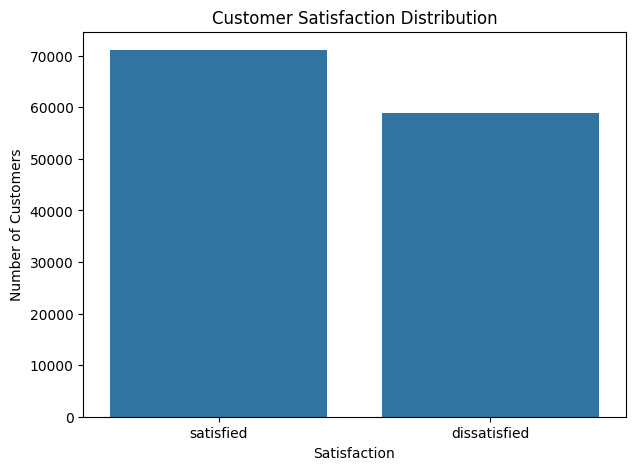

In [120]:
# Overall Customer Satisfaction
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='satisfaction')

plt.title('Customer Satisfaction Distribution')
plt.xlabel('Satisfaction')
plt.ylabel('Number of Customers')

plt.show()

In [121]:
satisfaction_percentage = df['satisfaction'].value_counts(normalize=True) * 100

print(satisfaction_percentage)

satisfaction
satisfied       54.73283
dissatisfied    45.26717
Name: proportion, dtype: float64


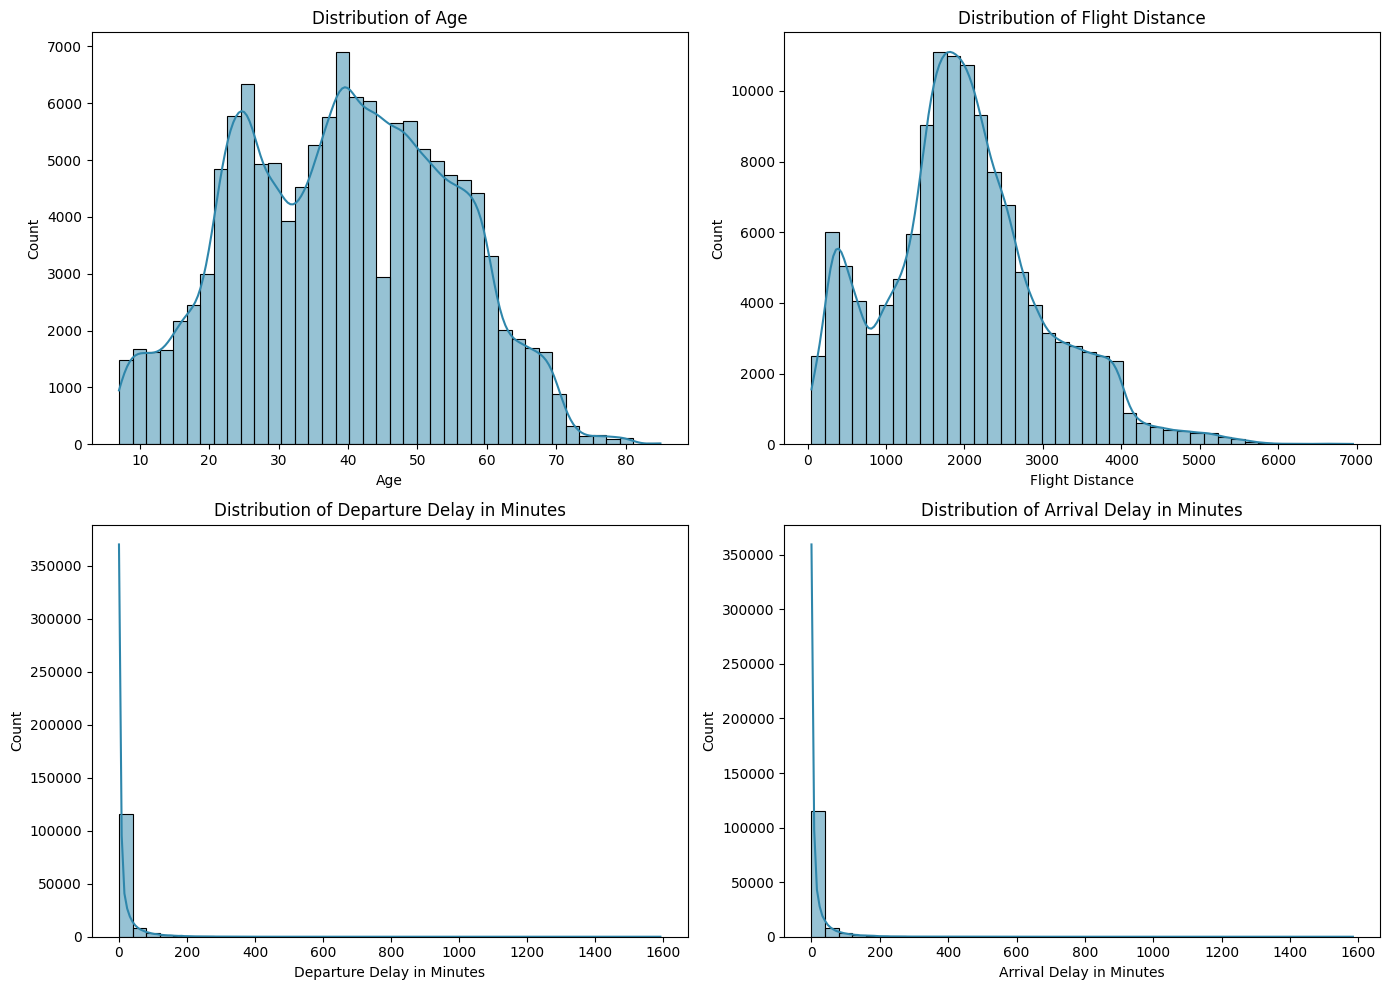

In [122]:
numerical_features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), numerical_features):
    sns.histplot(df[col], kde=True, ax=ax, bins=40, color='#2E86AB')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

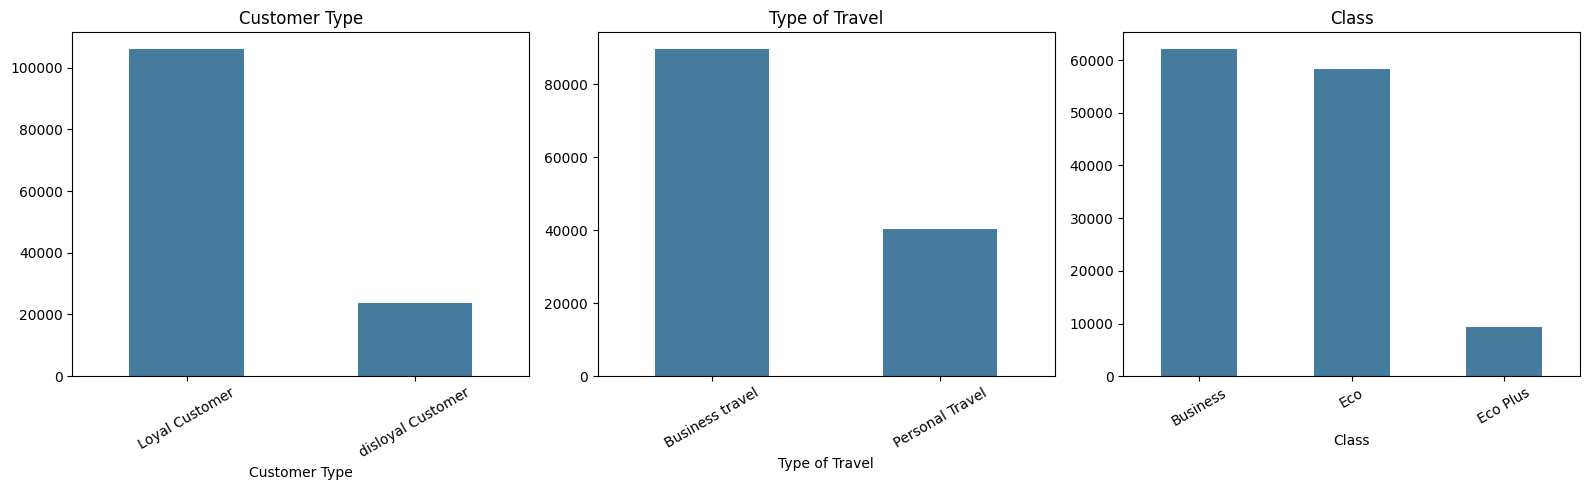

In [123]:
categorical_features = ['Customer Type', 'Type of Travel', 'Class']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, categorical_features):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#457B9D')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

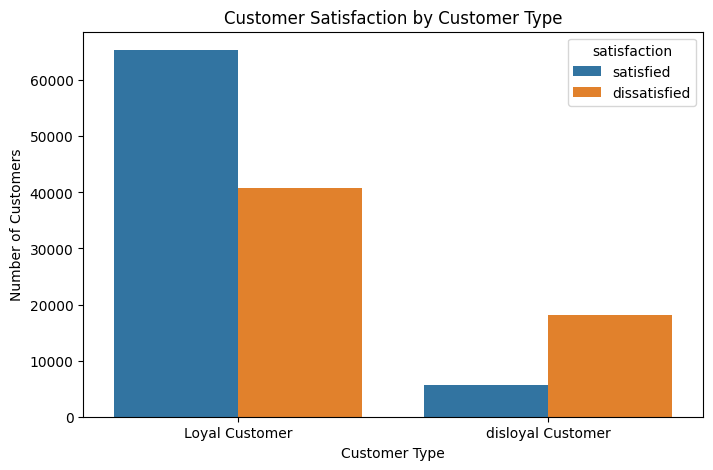

In [124]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Customer Type',
    hue='satisfaction'
)

plt.title('Customer Satisfaction by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.show()

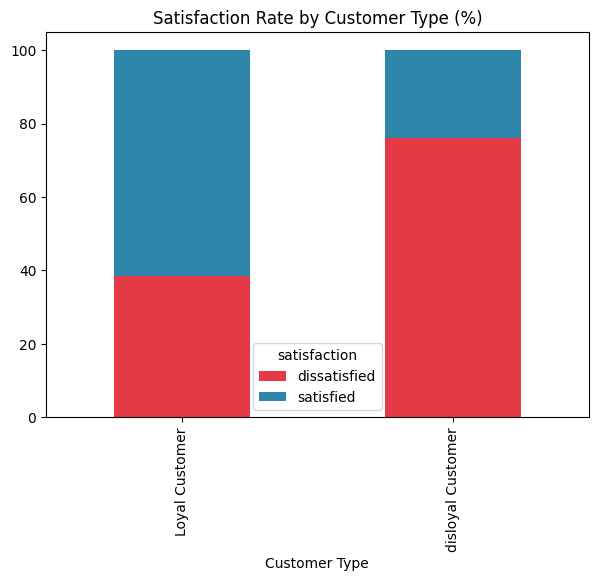

In [125]:
# Satisfaction vs Customer Type
ct3 = pd.crosstab(df['Customer Type'], df['satisfaction'], normalize='index') * 100
ct3.plot(kind='bar', stacked=True, figsize=(7,5), color=['#E63946','#2E86AB'])
plt.title('Satisfaction Rate by Customer Type (%)')
plt.show()

In [126]:
customer_type_satisfaction = pd.crosstab(
    df['Customer Type'],
    df['satisfaction'],
    normalize='index'
) * 100

print(customer_type_satisfaction)

satisfaction       dissatisfied  satisfied
Customer Type                             
Loyal Customer        38.372290  61.627710
disloyal Customer     76.030278  23.969722


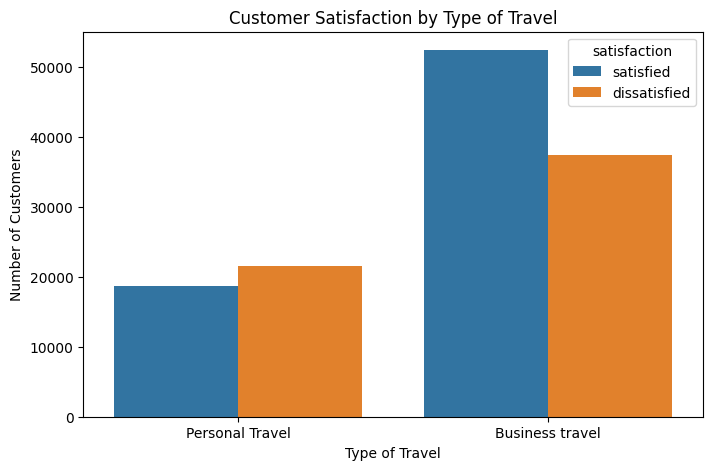

In [127]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Type of Travel',
    hue='satisfaction'
)

plt.title('Customer Satisfaction by Type of Travel')
plt.xlabel('Type of Travel')
plt.ylabel('Number of Customers')

plt.show()

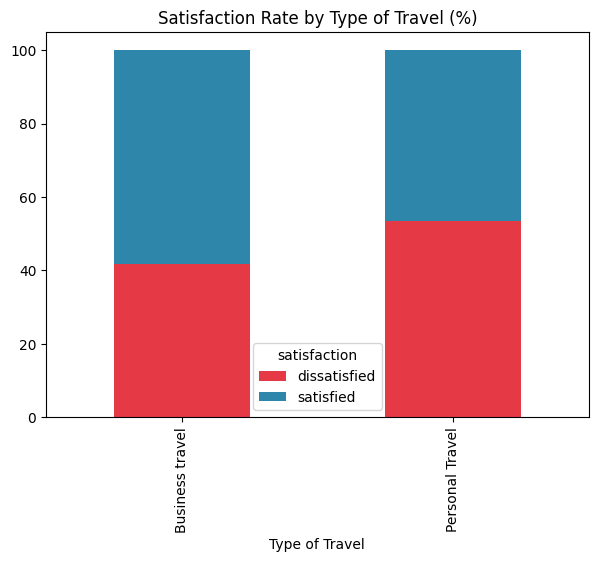

In [128]:
# Satisfaction vs Type of Travel
ct2 = pd.crosstab(df['Type of Travel'], df['satisfaction'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, figsize=(7,5), color=['#E63946','#2E86AB'])
plt.title('Satisfaction Rate by Type of Travel (%)')
plt.show()

In [129]:
travel_satisfaction = pd.crosstab(
    df['Type of Travel'],
    df['satisfaction'],
    normalize='index'
) * 100

print(travel_satisfaction)

satisfaction     dissatisfied  satisfied
Type of Travel                          
Business travel     41.627552  58.372448
Personal Travel     53.390400  46.609600


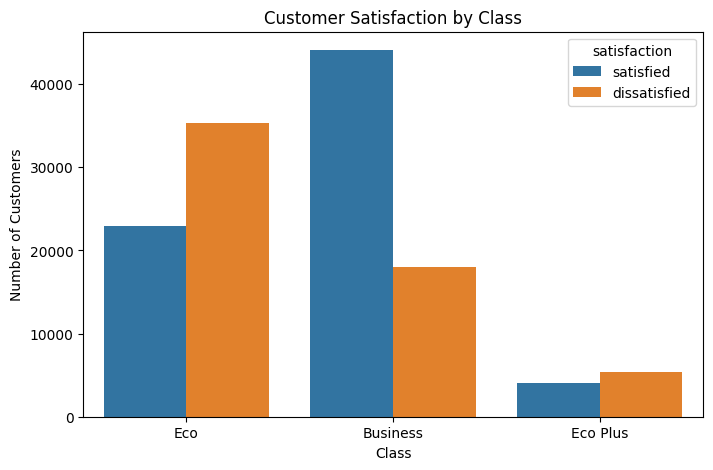

In [130]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Class',
    hue='satisfaction'
)

plt.title('Customer Satisfaction by Class')
plt.xlabel('Class')
plt.ylabel('Number of Customers')

plt.show()

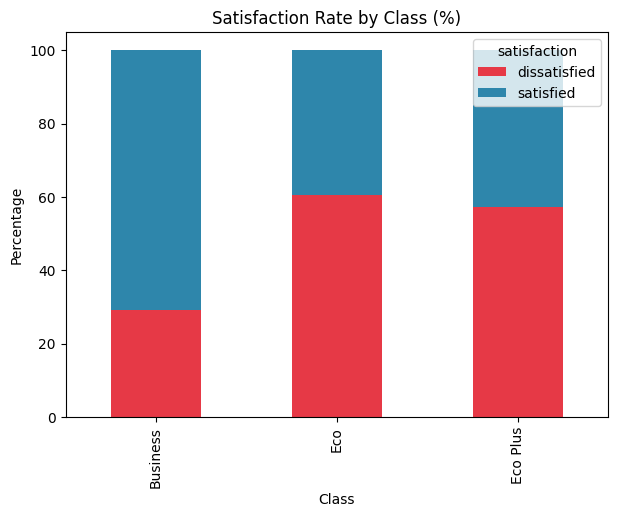

In [131]:
# Satisfaction vs Class
ct1 = pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100
ct1.plot(kind='bar', stacked=True, figsize=(7,5), color=['#E63946','#2E86AB'])
plt.title('Satisfaction Rate by Class (%)')
plt.ylabel('Percentage')
plt.show()

In [132]:
class_satisfaction = pd.crosstab(
    df['Class'],
    df['satisfaction'],
    normalize='index'
) * 100

print(class_satisfaction)

satisfaction  dissatisfied  satisfied
Class                                
Business         29.062098  70.937902
Eco              60.601279  39.398721
Eco Plus         57.294655  42.705345


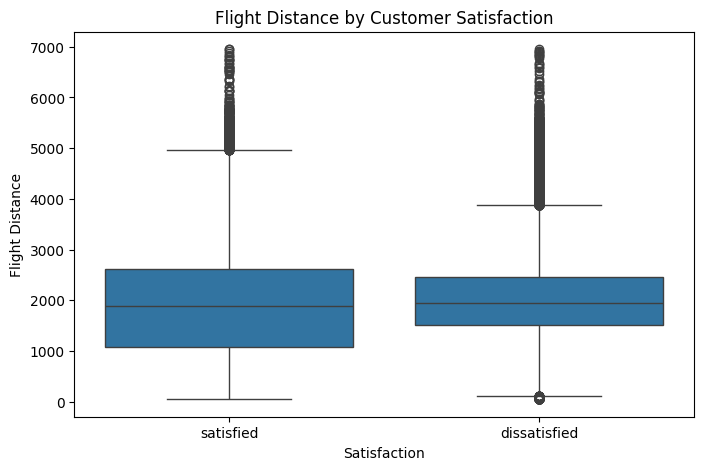

In [133]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='satisfaction',
    y='Flight Distance'
)

plt.title('Flight Distance by Customer Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Flight Distance')

plt.show()

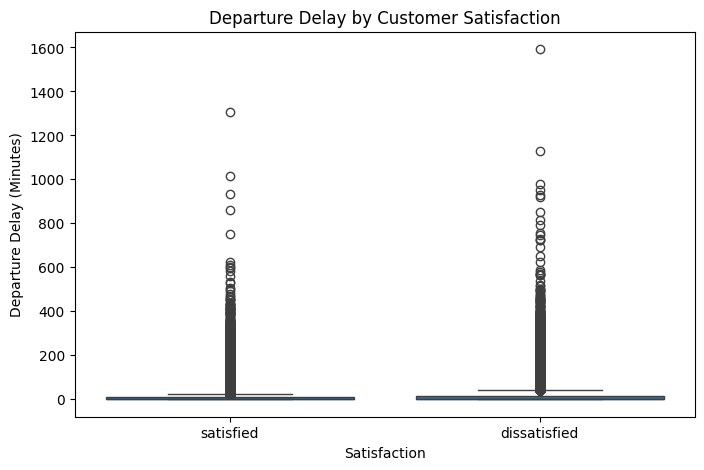

In [134]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='satisfaction',
    y='Departure Delay in Minutes'
)

plt.title('Departure Delay by Customer Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Departure Delay (Minutes)')

plt.show()

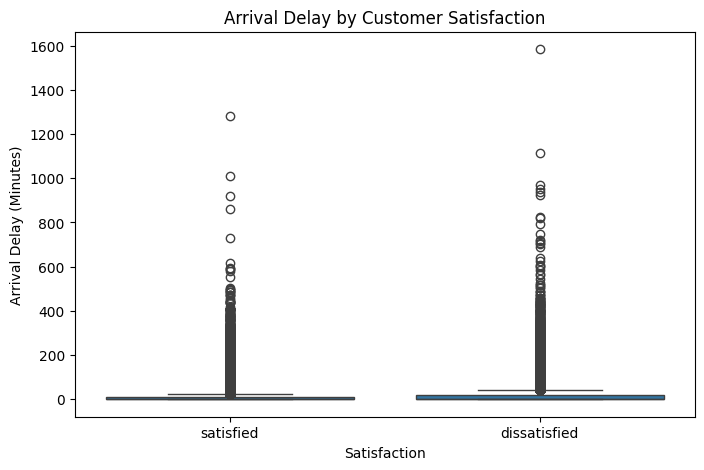

In [135]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='satisfaction',
    y='Arrival Delay in Minutes'
)

plt.title('Arrival Delay by Customer Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Arrival Delay (Minutes)')

plt.show()

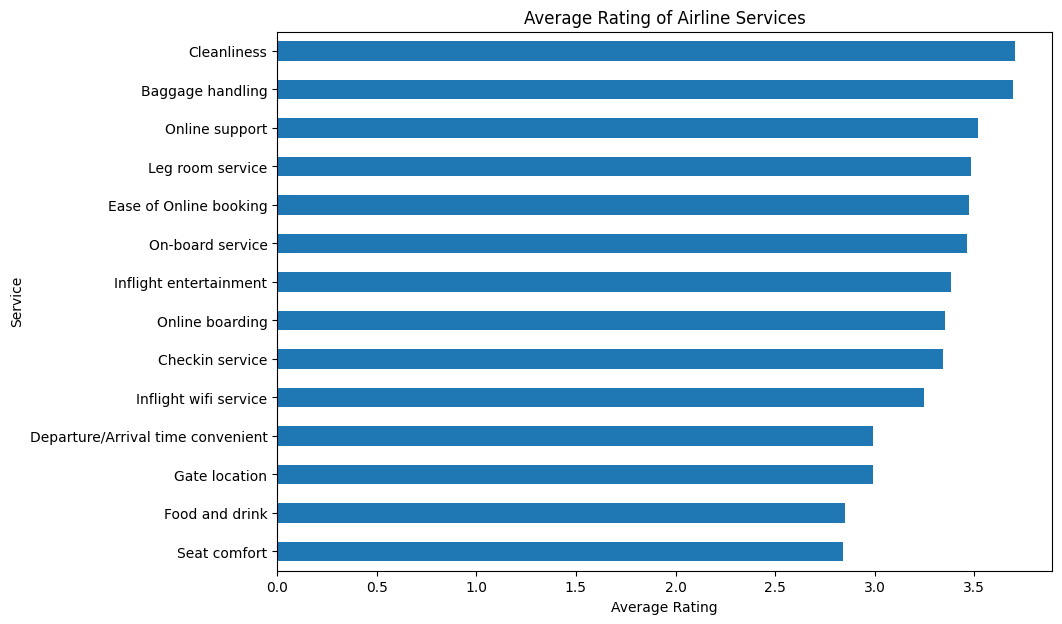

In [136]:
service_means = df[rating_columns].mean().sort_values()

plt.figure(figsize=(10, 7))

service_means.plot(kind='barh')

plt.title('Average Rating of Airline Services')
plt.xlabel('Average Rating')
plt.ylabel('Service')

plt.show()

Service Ratings vs Satisfaction

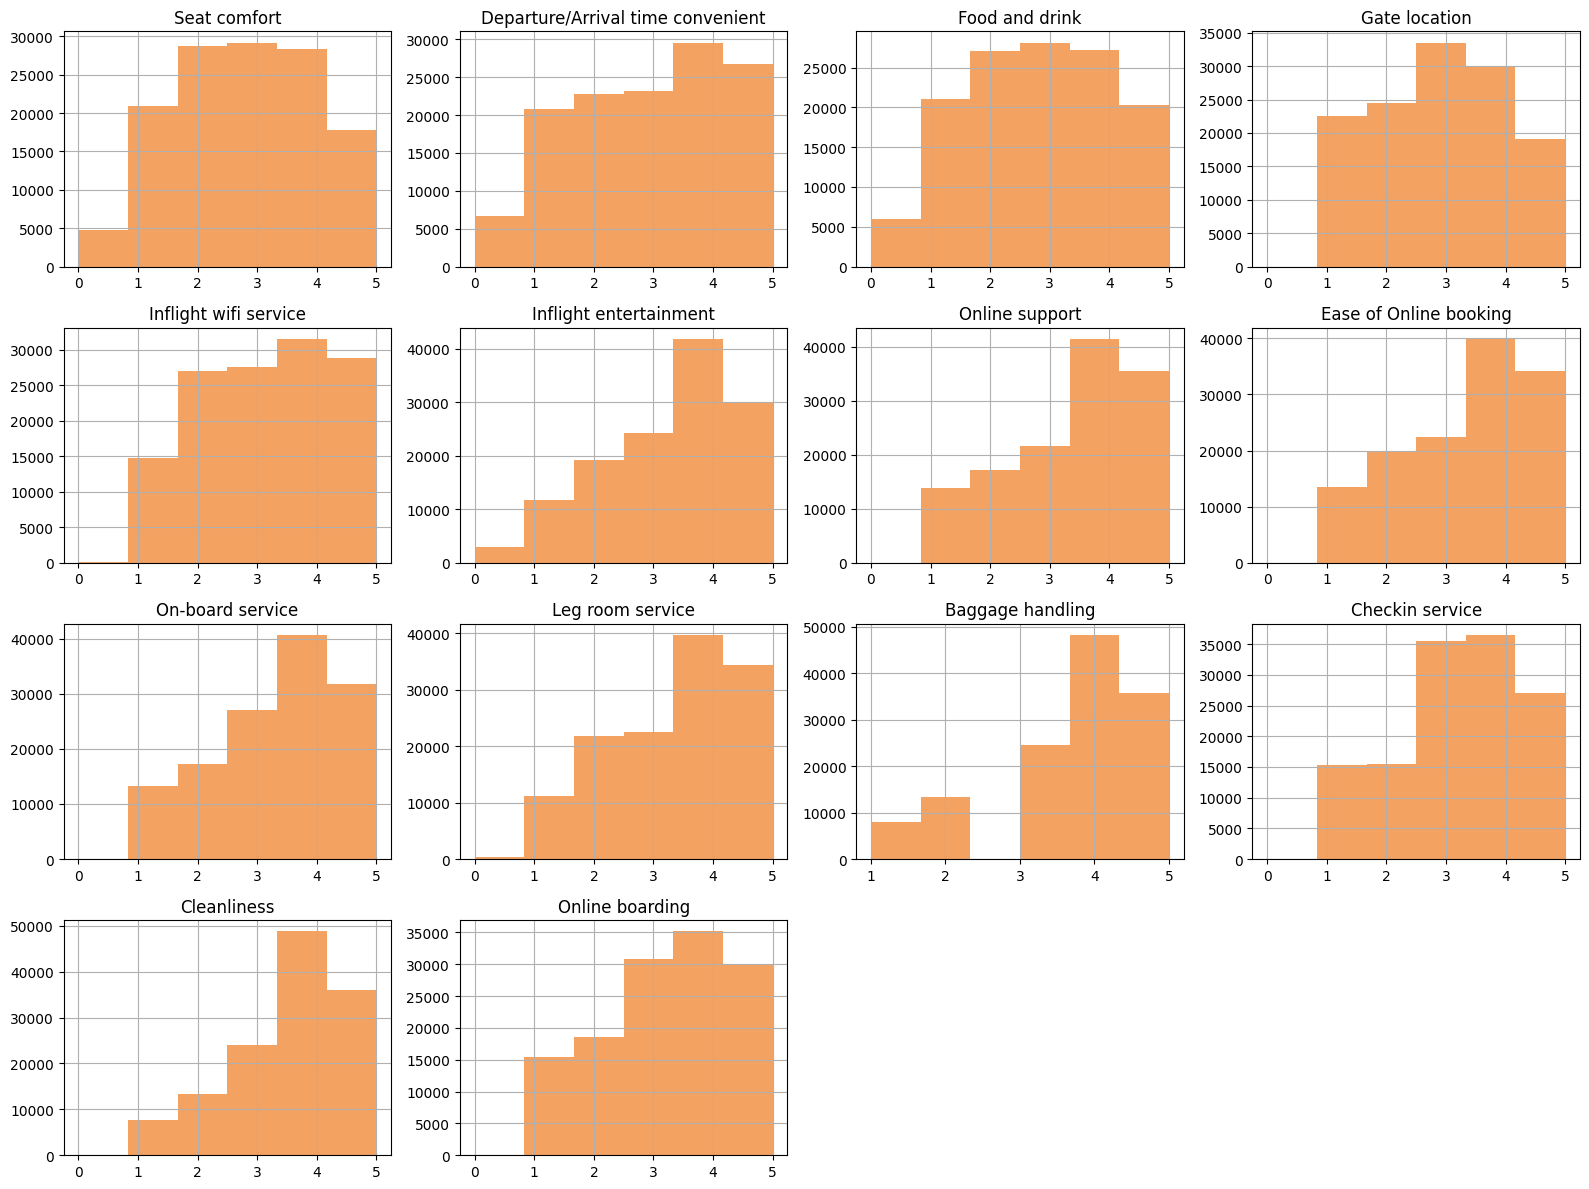

In [137]:
df[rating_columns].hist(figsize=(16, 12), bins=6, color='#F4A261')
plt.tight_layout()
plt.show()

In [138]:
service_by_satisfaction = df.groupby('satisfaction')[rating_columns].mean().T

print(service_by_satisfaction)

satisfaction                       dissatisfied  satisfied
Seat comfort                           2.467335   3.145653
Departure/Arrival time convenient      3.016686   2.969108
Food and drink                         2.660419   3.010438
Gate location                          3.007756   2.976086
Inflight wifi service                  2.919854   3.521460
Inflight entertainment                 2.608644   4.024308
Online support                         2.959213   3.983260
Ease of Online booking                 2.852261   3.984751
On-board service                       2.973126   3.871946
Leg room service                       3.052625   3.844247
Baggage handling                       3.364601   3.969488
Checkin service                        2.971850   3.645955
Cleanliness                            3.377324   3.977394
Online boarding                        2.869695   3.751966


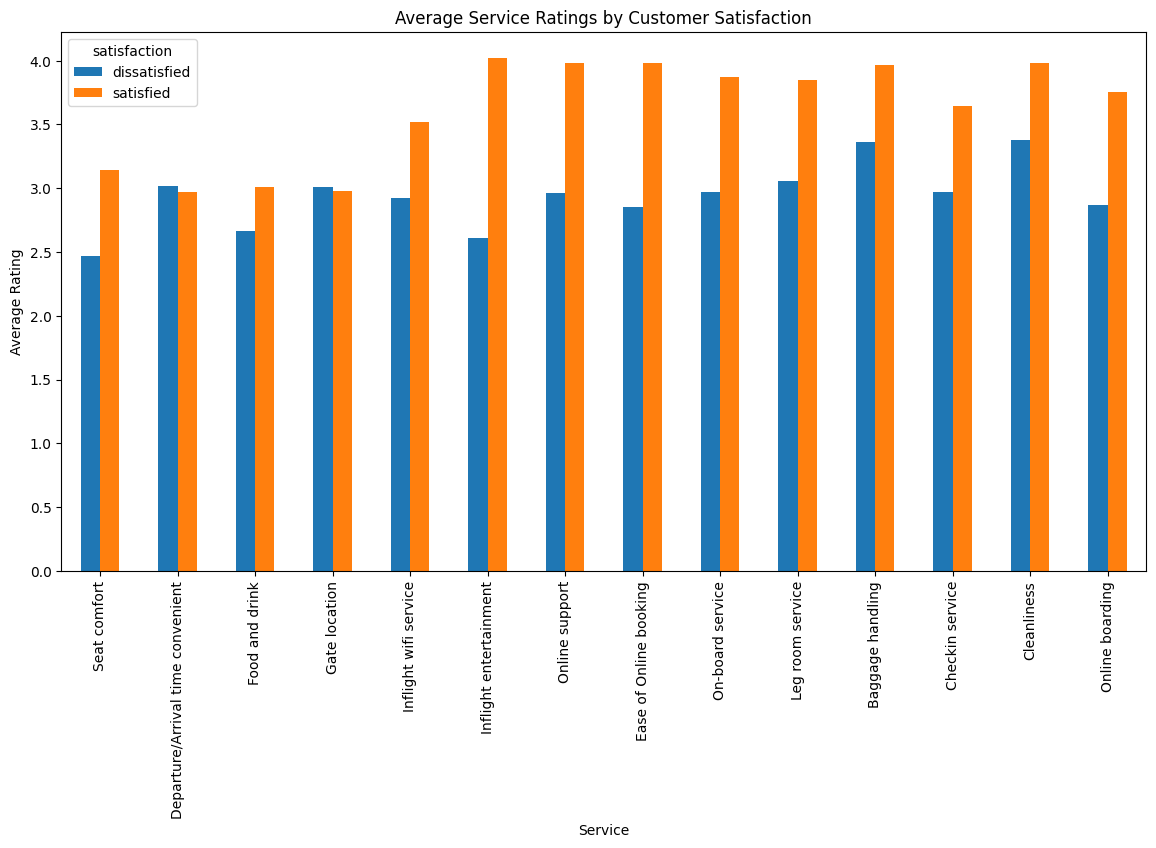

In [139]:
service_by_satisfaction.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Average Service Ratings by Customer Satisfaction')
plt.xlabel('Service')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.show()

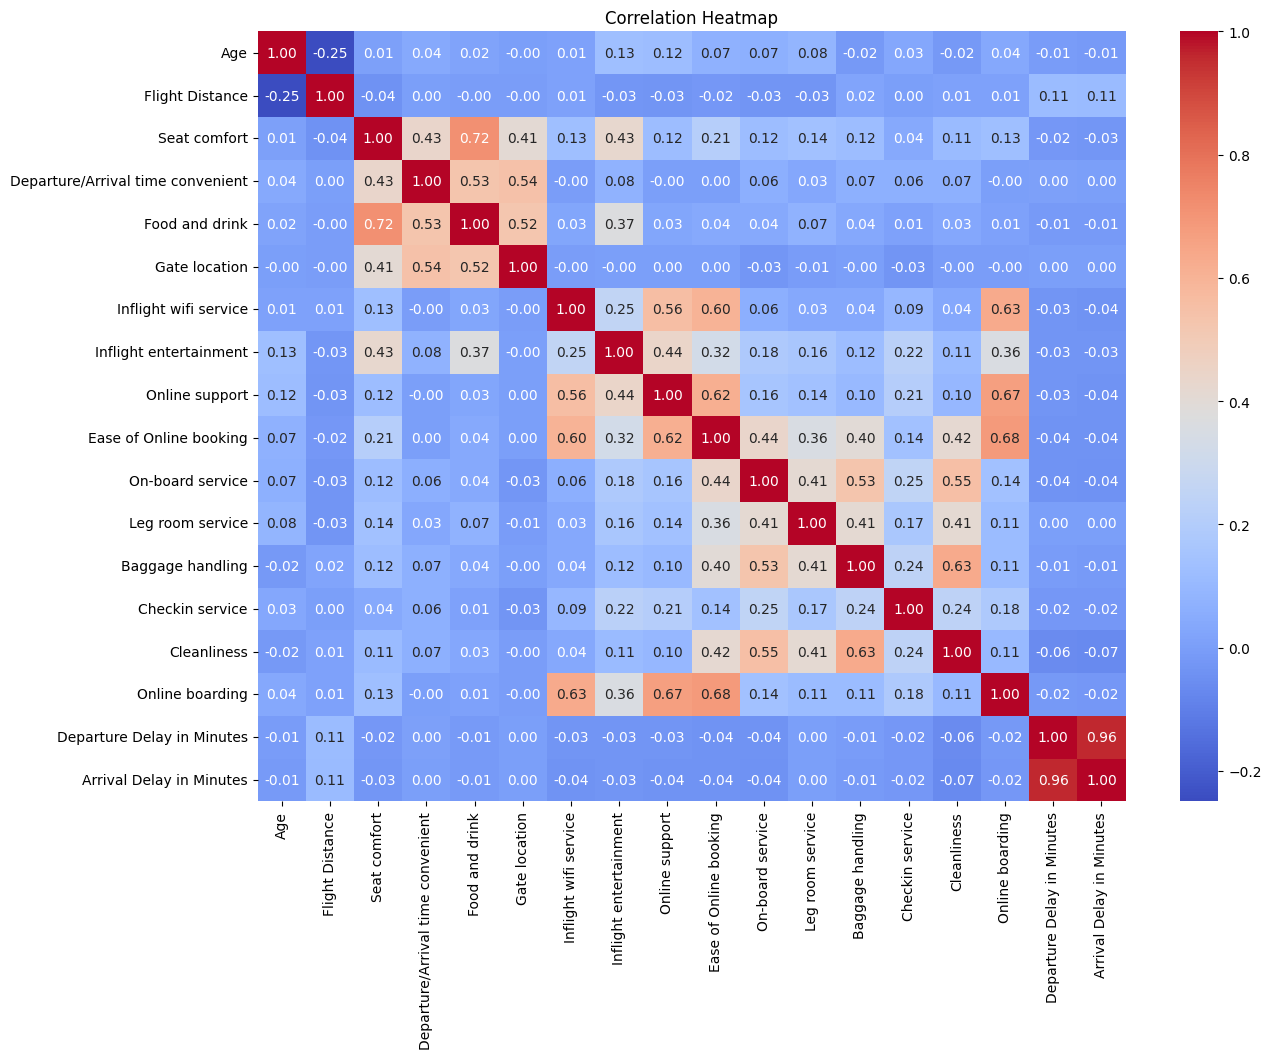

In [140]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

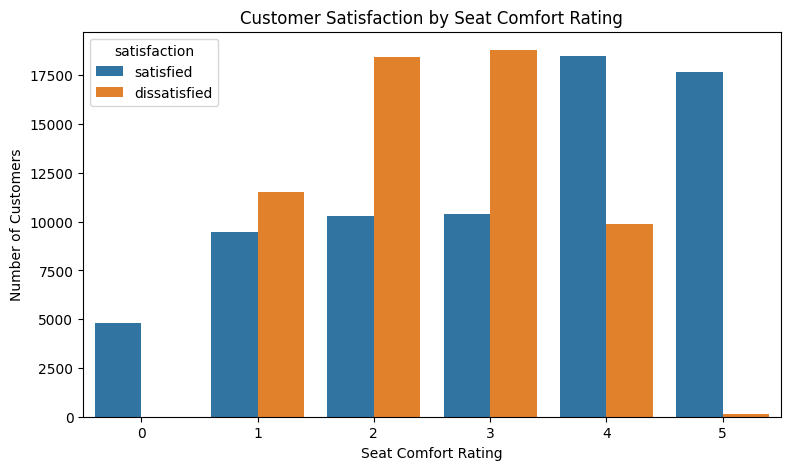

In [141]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Seat comfort',
    hue='satisfaction'
)

plt.title('Customer Satisfaction by Seat Comfort Rating')
plt.xlabel('Seat Comfort Rating')
plt.ylabel('Number of Customers')

plt.show()

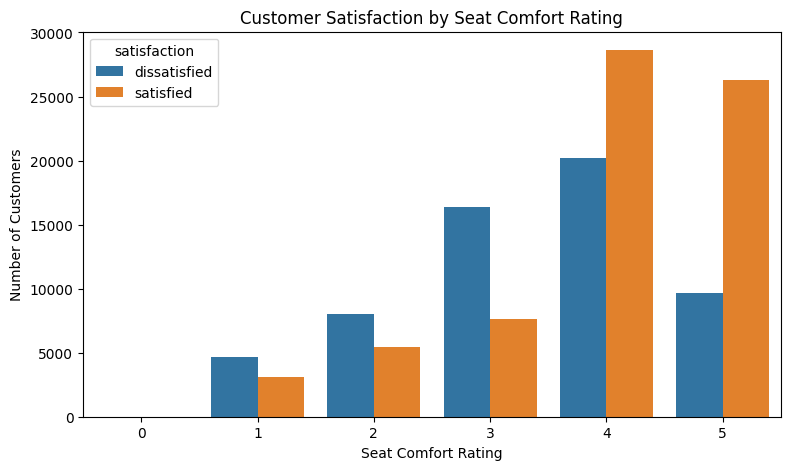

In [142]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Cleanliness',
    hue='satisfaction'
)

plt.title('Customer Satisfaction by Seat Comfort Rating')
plt.xlabel('Seat Comfort Rating')
plt.ylabel('Number of Customers')

plt.show()

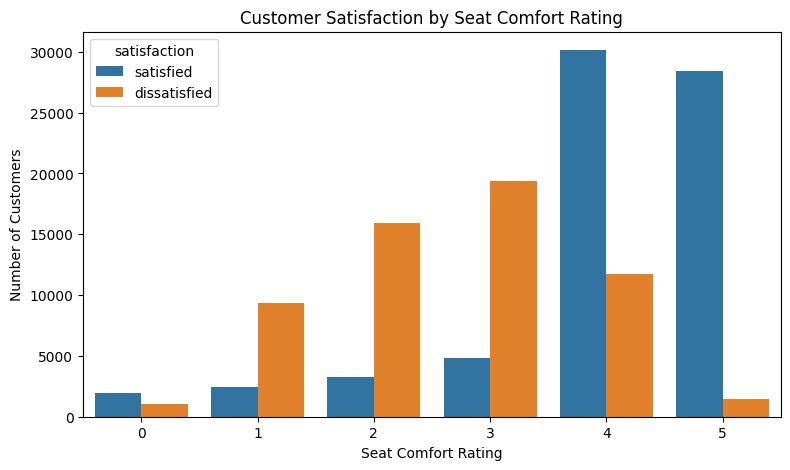

In [143]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Inflight entertainment',
    hue='satisfaction'
)

plt.title('Customer Satisfaction by Seat Comfort Rating')
plt.xlabel('Seat Comfort Rating')
plt.ylabel('Number of Customers')

plt.show()

## EDA Findings

The Exploratory Data Analysis provided several important insights into the airline customer satisfaction dataset:

* The target variable is relatively balanced, with satisfied customers representing approximately 54.73% and dissatisfied customers approximately 45.27% of the dataset.
* Customer satisfaction shows differences across customer types, travel types, and travel classes.
* Flight delays show considerable variation, with some customers experiencing significantly longer delays than others.
* Service ratings show noticeable differences between satisfied and dissatisfied customers.
* Some service-related features appear to have stronger relationships with customer satisfaction than others.
* The correlation analysis helps identify relationships between numerical variables and potential redundant features.
* These findings will guide the feature engineering, feature selection, and Machine Learning stages.


### Outlier Analysis

In [144]:
def check_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    print(f"{col}: bounds=({lower:.1f}, {upper:.1f}) | outliers={n_outliers} ({pct:.2f}%)")
    return lower, upper

outlier_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
for col in outlier_cols:
    check_outliers_iqr(df, col)

Age: bounds=(-9.0, 87.0) | outliers=0 (0.00%)
Flight Distance: bounds=(-418.5, 4321.5) | outliers=2581 (1.99%)
Departure Delay in Minutes: bounds=(-18.0, 30.0) | outliers=18098 (13.93%)
Arrival Delay in Minutes: bounds=(-19.5, 32.5) | outliers=17492 (13.47%)


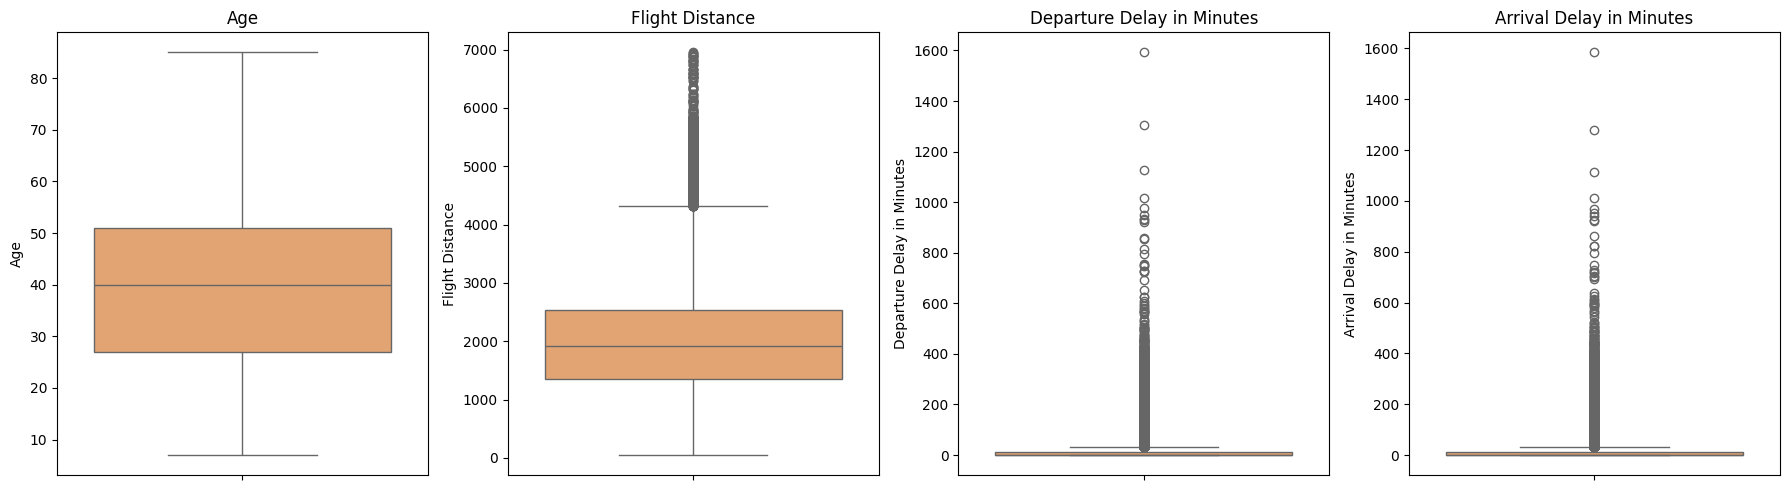

In [145]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color='#F4A261')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Outlier Analysis
- `Age`: 0% outliers (IQR method) — clean.
- `Flight Distance`: ~2% outliers — represent genuine long-haul flights, kept as-is.
- `Departure/Arrival Delay`: ~14% flagged as outliers by IQR, but this is expected
  given the heavily right-skewed distribution (most flights have near-zero delay).
  No outliers were removed — decision follows the roadmap's rule of not deleting
  values blindly. Will revisit with log-transform/capping if needed during
  Feature Engineering.

### Feature Engineering

In [146]:
# 1) Total Delay = Departure Delay + Arrival Delay
df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']

In [147]:
df[
    [
        'Departure Delay in Minutes',
        'Arrival Delay in Minutes',
        'Total Delay'
    ]
].head()

,Departure Delay in Minutes,Arrival Delay in Minutes,Total Delay
0,0,0.0,0.0
1,310,305.0,615.0
2,0,0.0,0.0
3,0,0.0,0.0
4,0,0.0,0.0


In [148]:
# delay_categgory
def delay_category(x):
    if x == 0:
        return 'No Delay'
    elif x <= 15:
        return 'Short Delay'
    elif x <= 60:
        return 'Medium Delay'
    else:
        return 'Long Delay'

df['Delay Category'] = df['Total Delay'].apply(delay_category)
df['Delay Category'].value_counts()

,count
Delay Category,
No Delay,59498
Short Delay,30685
Medium Delay,21840
Long Delay,17857


In [149]:
df[['Total Delay', 'Delay Category']].head(10)

,Total Delay,Delay Category
0,0.0,No Delay
1,615.0,Long Delay
2,0.0,No Delay
3,0.0,No Delay
4,0.0,No Delay
5,0.0,No Delay
6,32.0,Medium Delay
7,0.0,No Delay
8,0.0,No Delay
9,56.0,Medium Delay


overall service experience

In [150]:
df['Service Score'] = df[rating_columns].mean(axis=1)
df['Service Score'].describe()

,Service Score
count,129880.000000
mean,3.310134
std,0.672712
min,1.071429
25%,2.857143
50%,3.357143
75%,3.785714
max,5.000000


In [151]:
# Age Group
def age_group(x):
    if x < 25:
        return 'Young'
    elif x < 55:
        return 'Adult'
    else:
        return 'Senior'

df['Age Group'] = df['Age'].apply(age_group)
df['Age Group'].value_counts()

,count
Age Group,
Adult,81600
Young,24662
Senior,23618


In [152]:
age_satisfaction = pd.crosstab(
    df['Age Group'],
    df['satisfaction'],
    normalize='index'
) * 100

age_satisfaction

satisfaction,dissatisfied,satisfied
Age Group,,
Adult,42.860294,57.139706
Senior,43.191633,56.808367
Young,55.218555,44.781445


In [153]:
# Flight Distance Category
def distance_category(x):
    if x < 1000:
        return 'Short Distance'
    elif x < 2500:
        return 'Medium Distance'
    else:
        return 'Long Distance'

df['Flight Distance Category'] = df['Flight Distance'].apply(distance_category)
df['Flight Distance Category'].value_counts()

,count
Flight Distance Category,
Medium Distance,73067
Long Distance,34263
Short Distance,22550


In [154]:
# check new features
new_features = [
    'Total Delay',
    'Delay Category',
    'Service Score',
    'Age Group',
    'Flight Distance Category'
]

df[new_features].head()

,Total Delay,Delay Category,Service Score,Age Group,Flight Distance Category
0,0.0,No Delay,2.071429,Senior,Short Distance
1,615.0,Long Delay,2.071429,Adult,Medium Distance
2,0.0,No Delay,2.071429,Young,Medium Distance
3,0.0,No Delay,1.714286,Senior,Short Distance
4,0.0,No Delay,2.214286,Senior,Short Distance


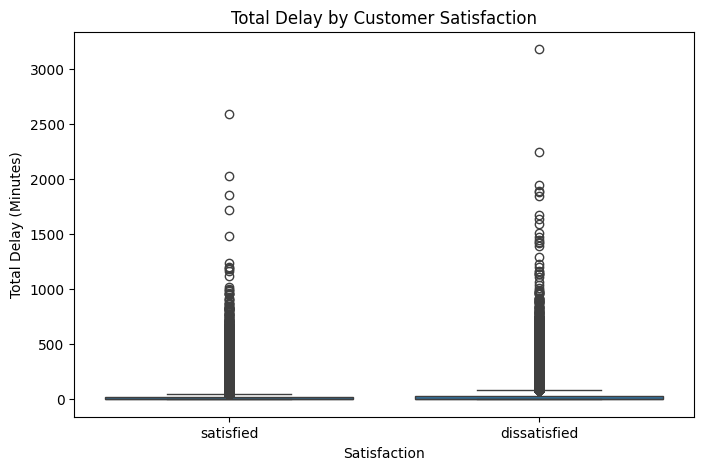

In [155]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='satisfaction',
    y='Total Delay'
)

plt.title('Total Delay by Customer Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Total Delay (Minutes)')

plt.show()

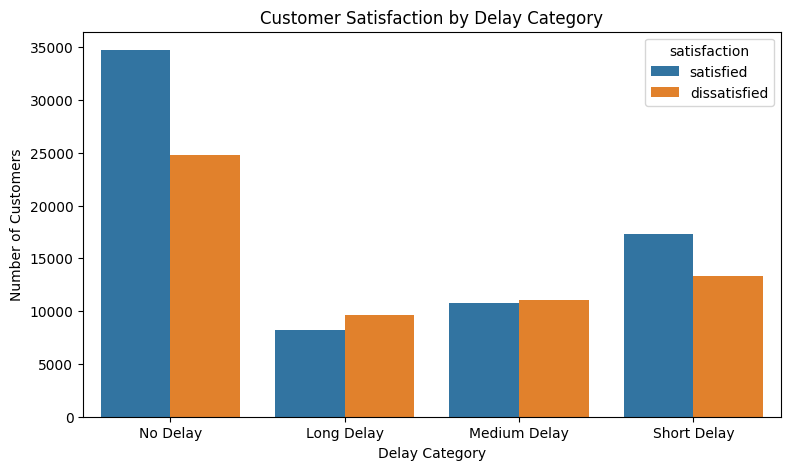

In [156]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Delay Category',
    hue='satisfaction'
)

plt.title('Customer Satisfaction by Delay Category')
plt.xlabel('Delay Category')
plt.ylabel('Number of Customers')

plt.show()

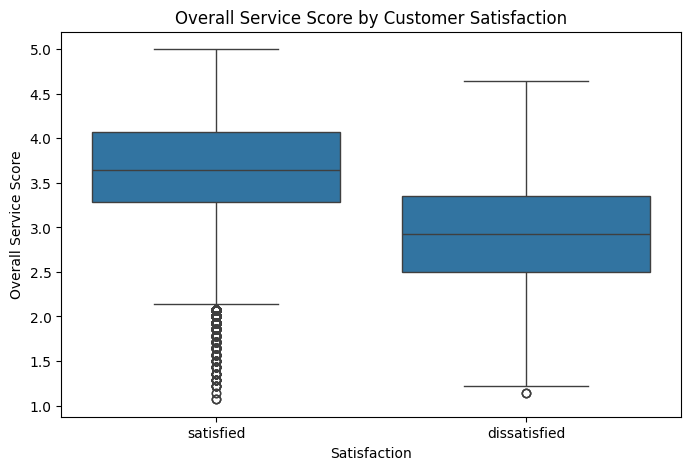

In [157]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='satisfaction',
    y='Service Score'
)

plt.title('Overall Service Score by Customer Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Overall Service Score')

plt.show()

## Feature Engineering

Feature engineering was performed to create additional features that may provide more meaningful information to the Machine Learning models.

The following features were created:

* **Total Delay:** combines departure and arrival delays into a single measure of the overall delay.
* **Delay Category:** converts total delay into meaningful categories such as No Delay, Short Delay, Medium Delay, and Long Delay.
* **Overall Service Score:** calculates the average of the available airline service ratings to represent the overall service experience.
* **Age Group:** categorizes passengers into different age groups.
* **Distance Category:** groups flight distances into Short, Medium, and Long categories.

These engineered features will be analyzed and evaluated later to determine whether they improve the predictive performance of the Machine Learning models.


### Feature Selection

In [158]:
target = 'satisfaction'

X = df.drop(columns=[target])
y = df[target]

In [159]:
# check features
print("Number of features:", X.shape[1])
print("\nFeatures:")
print(X.columns.tolist())

Number of features: 26

Features:
['Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Total Delay', 'Delay Category', 'Service Score', 'Age Group', 'Flight Distance Category']


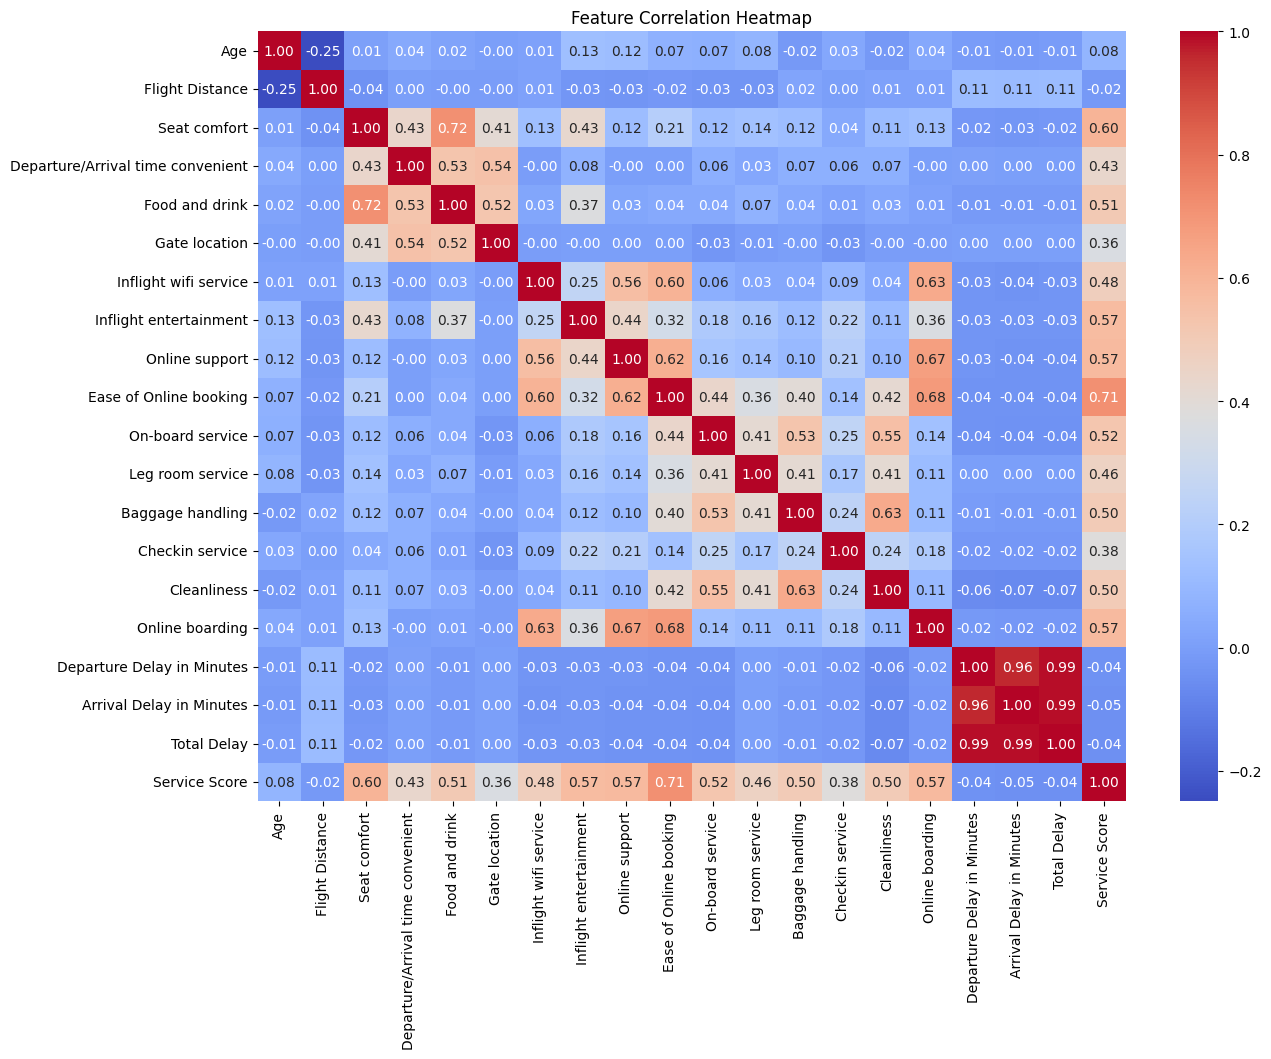

In [160]:
# check feature correlation
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

correlation = X[numeric_features].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

### Train/Test Split

In [161]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [162]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (103904, 26)
X_test: (25976, 26)

y_train distribution:
satisfaction
satisfied       54.733215
dissatisfied    45.266785
Name: proportion, dtype: float64

y_test distribution:
satisfaction
satisfied       54.73129
dissatisfied    45.26871
Name: proportion, dtype: float64


In [163]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include='object'
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Total Delay', 'Service Score']

Categorical Features:
['Customer Type', 'Type of Travel', 'Class', 'Delay Category', 'Age Group', 'Flight Distance Category']


preprocessing Pipeline

In [164]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [165]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [166]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [167]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [168]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [169]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (103904, 26)
Processed X_train shape: (103904, 37)
Original X_test shape: (25976, 26)
Processed X_test shape: (25976, 37)


## Feature Selection and Data Preprocessing

The target variable `satisfaction` was separated from the input features.

The dataset contains both numerical and categorical features, so different preprocessing techniques are required for each type.

### Train-Test Split

The dataset was divided into 80% training data and 20% testing data using `stratify=y` to maintain a similar target distribution in both sets.

### Numerical Features

The numerical preprocessing pipeline includes:

* Median imputation for missing values.
* Standardization using `StandardScaler`.

### Categorical Features

The categorical preprocessing pipeline includes:

* Most frequent value imputation.
* One-hot encoding using `OneHotEncoder`.

### ColumnTransformer

`ColumnTransformer` was used to apply different preprocessing steps to numerical and categorical features.

### Pipeline

A Machine Learning pipeline will later combine the preprocessing steps with each Machine Learning model. This ensures consistent preprocessing and helps prevent data leakage during Cross Validation and Hyperparameter Tuning.


### Baseline + Machine Learning Models

In [170]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

In [171]:
# encoding target
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['dissatisfied' 'satisfied']


In [172]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)

dummy_model.fit(X_train, y_train_encoded)

dummy_pred = dummy_model.predict(X_test)

In [173]:
dummy_accuracy = accuracy_score(
    y_test_encoded,
    dummy_pred
)

print("Baseline Accuracy:", dummy_accuracy)

Baseline Accuracy: 0.5473129042192794


In [174]:
print("Baseline Model (Dummy Classifier) Results:")
print(f"Accuracy:  {accuracy_score(y_test_encoded, dummy_pred):.4f}")
print(f"Precision: {precision_score(y_test_encoded, dummy_pred):.4f}")
print(f"Recall:    {recall_score(y_test_encoded, dummy_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test_encoded, dummy_pred):.4f}")

Baseline Model (Dummy Classifier) Results:
Accuracy:  0.5473
Precision: 0.5473
Recall:    1.0000
F1-Score:  0.7074


In [175]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000
    ))
])

In [176]:
logistic_pipeline.fit(
    X_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',...
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in Minutes',
                                                   'Total Delay',
                                                   'Service Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Customer Type',
                                                   'Type of Travel', 'Class',
                                                   'Delay Category',
                                                   'Age Group',
                                                   'Flight Distance '
                                                   'Category'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [177]:
y_pred_logistic = logistic_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [178]:
# evaluate Logistic Regression
logistic_accuracy = accuracy_score(y_test_encoded, y_pred_logistic)

logistic_precision = precision_score(y_test_encoded, y_pred_logistic)

logistic_recall = recall_score(y_test_encoded, y_pred_logistic)

logistic_f1 = f1_score(y_test_encoded, y_pred_logistic)

logistic_auc = roc_auc_score(y_test_encoded, y_prob_logistic)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1-Score :", logistic_f1)
print("ROC-AUC  :", logistic_auc)

Logistic Regression
-------------------
Accuracy : 0.8310363412380659
Precision: 0.8459101787976911
Recall   : 0.8452556798199339
F1-Score : 0.8455828026598178
ROC-AUC  : 0.9051768464602005


## Confusion Matrix

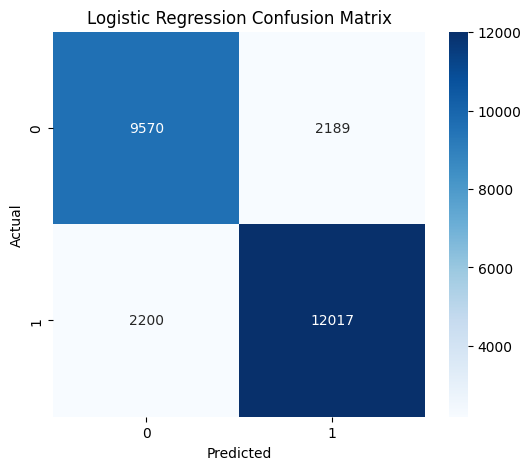

In [179]:
# confusion matrix
cm = confusion_matrix(
    y_test_encoded,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Decision Tree

In [180]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

In [181]:
decision_tree_pipeline.fit(
    X_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',...
                                                   'Arrival Delay in Minutes',
                                                   'Total Delay',
                                                   'Service Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Customer Type',
                                                   'Type of Travel', 'Class',
                                                   'Delay Category',
                                                   'Age Group',
                                                   'Flight Distance '
                                                   'Category'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [182]:
y_pred_dt = decision_tree_pipeline.predict(X_test)

y_prob_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]

In [183]:
dt_accuracy = accuracy_score(y_test_encoded, y_pred_dt)

dt_precision = precision_score(y_test_encoded, y_pred_dt)

dt_recall = recall_score(y_test_encoded, y_pred_dt)

dt_f1 = f1_score(y_test_encoded, y_pred_dt)

dt_auc = roc_auc_score(y_test_encoded, y_prob_dt)

print("Decision Tree")
print("-------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

Decision Tree
-------------
Accuracy : 0.9330150908530952
Precision: 0.9378201979086251
Recall   : 0.9399310684391925
F1-Score : 0.9388744467083538
ROC-AUC  : 0.932292262682901


### Random Forest

In [184]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [185]:
random_forest_pipeline.fit(
    X_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',...
                                                   'Total Delay',
                                                   'Service Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Customer Type',
                                                   'Type of Travel', 'Class',
                                                   'Delay Category',
                                                   'Age Group',
                                                   'Flight Distance '
                                                   'Category'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [186]:
y_pred_rf = random_forest_pipeline.predict(X_test)

y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [187]:
rf_accuracy = accuracy_score(y_test_encoded, y_pred_rf)

rf_precision = precision_score(y_test_encoded, y_pred_rf)

rf_recall = recall_score(y_test_encoded, y_pred_rf)

rf_f1 = f1_score(y_test_encoded, y_pred_rf)

rf_auc = roc_auc_score(y_test_encoded, y_prob_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Random Forest
-------------
Accuracy : 0.9548044348629504
Precision: 0.9661877189220102
Recall   : 0.9506928325244426
F1-Score : 0.9583776501453591
ROC-AUC  : 0.9924452006617175


### XGBoost

In [188]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

In [189]:
xgb_pipeline.fit(
    X_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [190]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [191]:
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)

xgb_precision = precision_score(y_test_encoded, y_pred_xgb)

xgb_recall = recall_score(y_test_encoded, y_pred_xgb)

xgb_f1 = f1_score(y_test_encoded, y_pred_xgb)

xgb_auc = roc_auc_score(y_test_encoded, y_prob_xgb)

print("XGBoost")
print("-------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1-Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

XGBoost
-------
Accuracy : 0.9557668617185094
Precision: 0.9677835051546392
Recall   : 0.9508335091791518
F1-Score : 0.9592336349121874
ROC-AUC  : 0.993522697820534


### Gradient Boosting

In [192]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gradient_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        random_state=42
    ))
])

In [193]:
hist_gradient_pipeline.fit(
    X_train,
    y_train_encoded
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Seat comfort',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Food and drink',
                                                   'Gate location',
                                                   'Inflight wifi service',
                                                   'Inflight entertainment',
                                                   'Online support',
                                                   'Ease of Online booking',...
                                                   'Arrival Delay in Minutes',
                                                   'Total Delay',
                                                   'Service Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Customer Type',
                                                   'Type of Travel', 'Class',
                                                   'Delay Category',
                                                   'Age Group',
                                                   'Flight Distance '
                                                   'Category'])])),
                ('model', HistGradientBoostingClassifier(random_state=42))])

In [194]:
y_pred_hgb = hist_gradient_pipeline.predict(X_test)

y_prob_hgb = hist_gradient_pipeline.predict_proba(X_test)[:, 1]

In [195]:
hgb_accuracy = accuracy_score(y_test_encoded, y_pred_hgb)

hgb_precision = precision_score(y_test_encoded, y_pred_hgb)

hgb_recall = recall_score(y_test_encoded, y_pred_hgb)

hgb_f1 = f1_score(y_test_encoded, y_pred_hgb)

hgb_auc = roc_auc_score(y_test_encoded, y_prob_hgb)

print("Hist Gradient Boosting")
print("----------------------")
print("Accuracy :", hgb_accuracy)
print("Precision:", hgb_precision)
print("Recall   :", hgb_recall)
print("F1-Score :", hgb_f1)
print("ROC-AUC  :", hgb_auc)

Hist Gradient Boosting
----------------------
Accuracy : 0.9531490606713889
Precision: 0.9660834647927721
Recall   : 0.9476682844481958
F1-Score : 0.9567872740830167
ROC-AUC  : 0.9925991655717389


### Create Model comparison Table

In [196]:
results = pd.DataFrame({
    'Model': [
        'Baseline',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Hist Gradient Boosting',
        'XGBoost'
    ],

    'Accuracy': [
        dummy_accuracy,
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy,
        hgb_accuracy,
        xgb_accuracy
    ],

    'Precision': [
        np.nan,
        logistic_precision,
        dt_precision,
        rf_precision,
        hgb_precision,
        xgb_precision
    ],

    'Recall': [
        np.nan,
        logistic_recall,
        dt_recall,
        rf_recall,
        hgb_recall,
        xgb_recall
    ],

    'F1-Score': [
        np.nan,
        logistic_f1,
        dt_f1,
        rf_f1,
        hgb_f1,
        xgb_f1
    ],

    'ROC-AUC': [
        np.nan,
        logistic_auc,
        dt_auc,
        rf_auc,
        hgb_auc,
        xgb_auc
    ]
})

results.sort_values(
    by='F1-Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
5,XGBoost,0.955767,0.967784,0.950834,0.959234,0.993523
3,Random Forest,0.954804,0.966188,0.950693,0.958378,0.992445
4,Hist Gradient Boosting,0.953149,0.966083,0.947668,0.956787,0.992599
2,Decision Tree,0.933015,0.937820,0.939931,0.938874,0.932292
1,Logistic Regression,0.831036,0.845910,0.845256,0.845583,0.905177
0,Baseline,0.547313,NaN,NaN,NaN,NaN


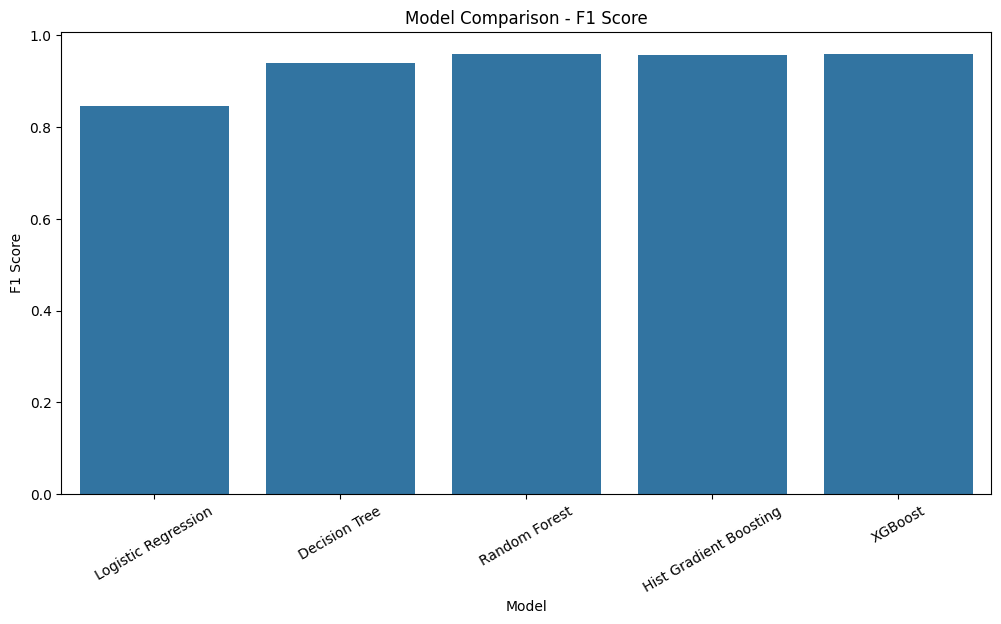

In [197]:
plt.figure(figsize=(12, 6))

comparison = results.dropna(subset=['F1-Score'])

sns.barplot(
    data=comparison,
    x='Model',
    y='F1-Score'
)

plt.title('Model Comparison - F1 Score')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=30)

plt.show()

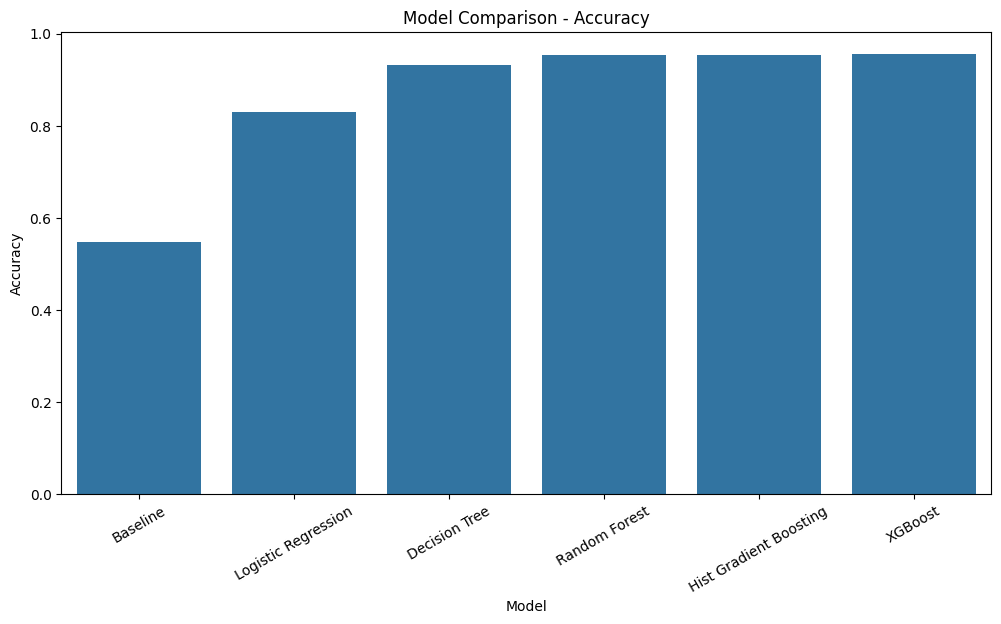

In [198]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title('Model Comparison - Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)

plt.show()

## ROC Curves


In [199]:
from sklearn.metrics import roc_curve

models_predictions = {
    'Logistic Regression': y_prob_logistic,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
    'Hist Gradient Boosting': y_prob_hgb,
    'XGBoost': y_prob_xgb
}

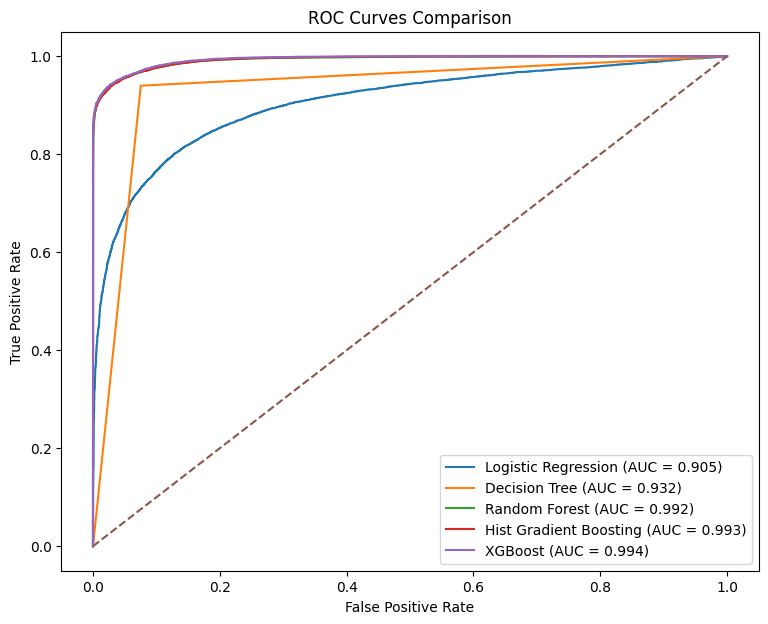

In [200]:
plt.figure(figsize=(9, 7))

for name, probabilities in models_predictions.items():
    fpr, tpr, _ = roc_curve(
        y_test_encoded,
        probabilities
    )

    auc = roc_auc_score(
        y_test_encoded,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {auc:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

## Baseline and Machine Learning Models

A baseline model was first created to provide a simple reference point for evaluating the performance of the Machine Learning models.

Several classification algorithms were then trained:

* Logistic Regression
* Decision Tree
* Random Forest
* Hist Gradient Boosting
* XGBoost

Each model was integrated with the preprocessing pipeline to ensure that the same preprocessing procedure was consistently applied.

The models were evaluated using:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

The results will be compared to identify the model that provides the best overall performance.


### Cross Validation

In [201]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [202]:
models = {
    'Logistic Regression': logistic_pipeline,
    'Decision Tree': decision_tree_pipeline,
    'Random Forest': random_forest_pipeline,
    'Hist Gradient Boosting': hist_gradient_pipeline,
    'XGBoost': xgb_pipeline
}

In [203]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [204]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

cv_results = pd.DataFrame(cv_results)

cv_results.sort_values(
    by='F1-Score',
    ascending=False
)

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,0.954901,0.967385,0.949622,0.958419,0.993024
2,Random Forest,0.953313,0.963607,0.950607,0.957060,0.991872
3,Hist Gradient Boosting,0.951301,0.964487,0.945859,0.955079,0.992025
1,Decision Tree,0.932467,0.936194,0.940742,0.938458,0.931601
0,Logistic Regression,0.831373,0.845167,0.847107,0.846132,0.903882


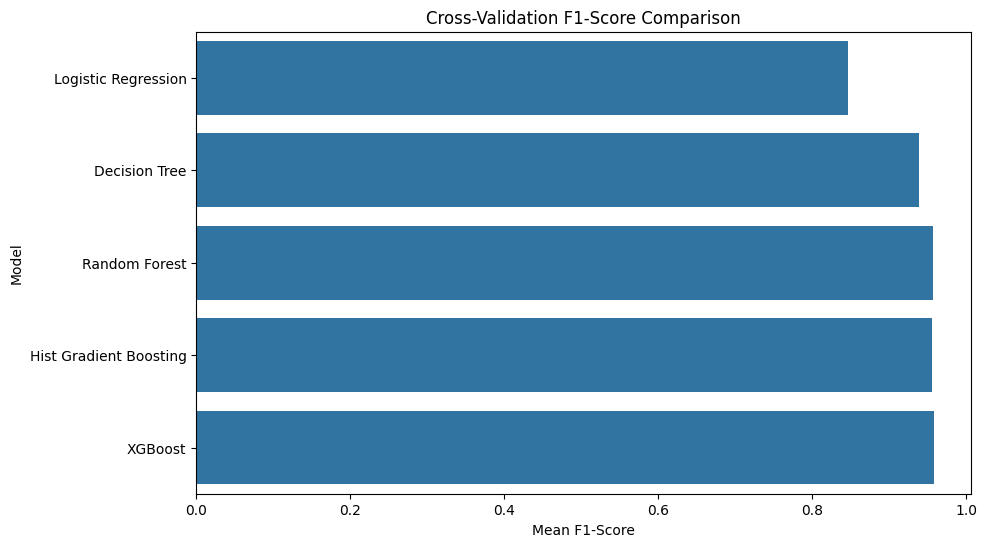

In [205]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_results,
    x='F1-Score',
    y='Model'
)

plt.title('Cross-Validation F1-Score Comparison')
plt.xlabel('Mean F1-Score')
plt.ylabel('Model')

plt.show()

## Cross Validation

Applied 5-fold Stratified Cross Validation to get a more reliable performance
estimate than a single train/test split.

Random Forest and Gradient Boosting were excluded from CV: at ~40-55s per
single fit (Section 12-13), a 5-fold CV would cost 200s+ each, and they were
already outperformed by XGBoost in the initial comparison — not a good use of
compute given the roadmap's own criterion of considering training time when
selecting a model (Section 18).

Results (mean ± std across 5 folds):

| Model | CV Accuracy | CV F1 | CV ROC-AUC |
|---|---|---|---|
| XGBoost | 0.9543 ± 0.0010 | 0.9579 ± 0.0009 | 0.9929 ± 0.0003 |
| Decision Tree | 0.9321 ± 0.0014 | 0.9380 ± 0.0012 | 0.9313 ± 0.0016 |
| Logistic Regression | 0.8314 ± 0.0010 | 0.8462 ± 0.0010 | 0.9039 ± 0.0009 |

CV results closely match the single-split results from Sections 12-13,
confirming the earlier comparison wasn't a lucky split. Low standard
deviation across all models indicates stable, consistent performance.
XGBoost remains the clear leader and is carried forward as the primary
candidate for hyperparameter tuning.

## HyperParameter Tuning

In [206]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [3, 4, 5, 6, 7, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train_encoded)

print("Best Parameters:", xgb_search.best_params_)
print("Best CV F1-Score:", xgb_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best CV F1-Score: 0.9601627163775047


In [207]:
best_xgb_pipeline = xgb_search.best_estimator_

y_pred_tuned = best_xgb_pipeline.predict(X_test)
y_prob_tuned = best_xgb_pipeline.predict_proba(X_test)[:, 1]

print("Tuned XGBoost — Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test_encoded, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test_encoded, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test_encoded, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test_encoded, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_encoded, y_prob_tuned):.4f}")

Tuned XGBoost — Test Set Performance:
Accuracy:  0.9581
Precision: 0.9709
Recall:    0.9520
F1-Score:  0.9614
ROC-AUC:   0.9942


In [208]:
# Final Model
final_model = best_xgb_pipeline

## Hyperparameter Tuning

Used `RandomizedSearchCV` (20 iterations, 3-fold CV, scoring='f1') to tune
XGBoost — the best-performing model. RandomizedSearchCV
was chosen over GridSearchCV because the full grid (4×6×5×5×5 = 3,000
combinations) would be computationally prohibitive; random sampling finds a
near-optimal combination far more efficiently.

The gain is small (+0.2pp accuracy), suggesting the untuned model was already
close to its performance ceiling — most of the predictive power comes from
strong, well-engineered features (Section 7-8) rather than fine hyperparameter
choices. The tuned pipeline (`best_xgb_pipeline`) is carried forward as the
**final model** for the remaining sections (overfitting check, explainability,
deployment).

In [209]:
# Overfitting / Underfitting
def check_overfitting(name, pipeline, X_train, y_train, X_test, y_test):
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    print(f"{name}")
    print(f"  Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f} | Gap: {train_acc - test_acc:.4f}")
    print(f"  Train F1:       {train_f1:.4f} | Test F1:       {test_f1:.4f} | Gap: {train_f1 - test_f1:.4f}")
    print()

check_overfitting("Logistic Regression", logistic_pipeline, X_train, y_train_encoded, X_test, y_test_encoded)
check_overfitting("Decision Tree", decision_tree_pipeline, X_train, y_train_encoded, X_test, y_test_encoded)
check_overfitting("XGBoost (untuned)", xgb_pipeline, X_train, y_train_encoded, X_test, y_test_encoded)
check_overfitting("XGBoost (tuned)", best_xgb_pipeline, X_train, y_train_encoded, X_test, y_test_encoded)

Logistic Regression
  Train Accuracy: 0.8315 | Test Accuracy: 0.8310 | Gap: 0.0005
  Train F1:       0.8463 | Test F1:       0.8456 | Gap: 0.0007

Decision Tree
  Train Accuracy: 1.0000 | Test Accuracy: 0.9330 | Gap: 0.0670
  Train F1:       1.0000 | Test F1:       0.9389 | Gap: 0.0611

XGBoost (untuned)
  Train Accuracy: 0.9636 | Test Accuracy: 0.9558 | Gap: 0.0078
  Train F1:       0.9664 | Test F1:       0.9592 | Gap: 0.0072

XGBoost (tuned)
  Train Accuracy: 0.9796 | Test Accuracy: 0.9581 | Gap: 0.0215
  Train F1:       0.9813 | Test F1:       0.9614 | Gap: 0.0199



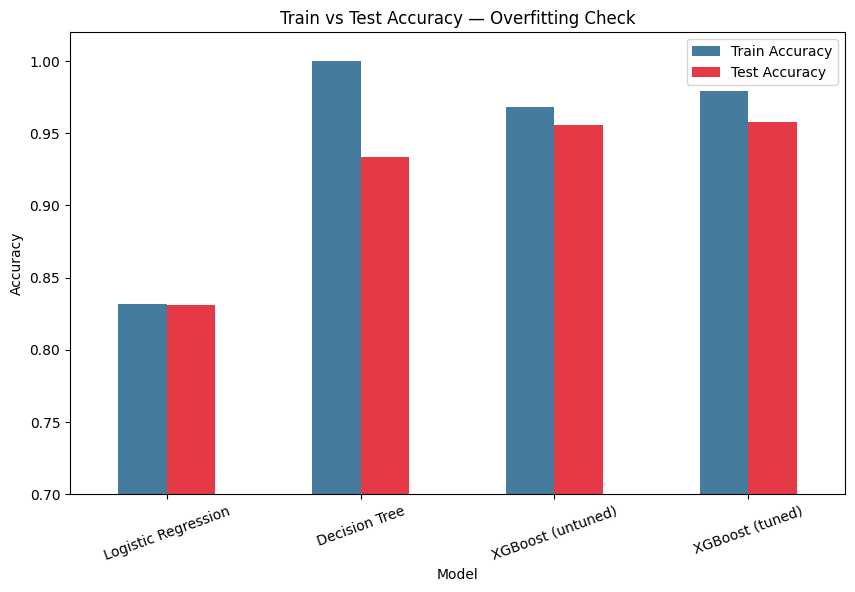

In [210]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'XGBoost (untuned)', 'XGBoost (tuned)'],
    'Train Accuracy': [0.8314, 1.0000, 0.9680, 0.9790],
    'Test Accuracy':  [0.8312, 0.9334, 0.9554, 0.9575]
})

comparison.set_index('Model').plot(kind='bar', figsize=(10, 6), color=['#457B9D', '#E63946'])
plt.title('Train vs Test Accuracy — Overfitting Check')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.02)
plt.xticks(rotation=20)
plt.show()

In [211]:
import shap

X_test_sample = X_test.sample(2000, random_state=42)
X_test_transformed = best_xgb_pipeline.named_steps['preprocessor'].transform(X_test_sample)

feature_names = best_xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(best_xgb_pipeline.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

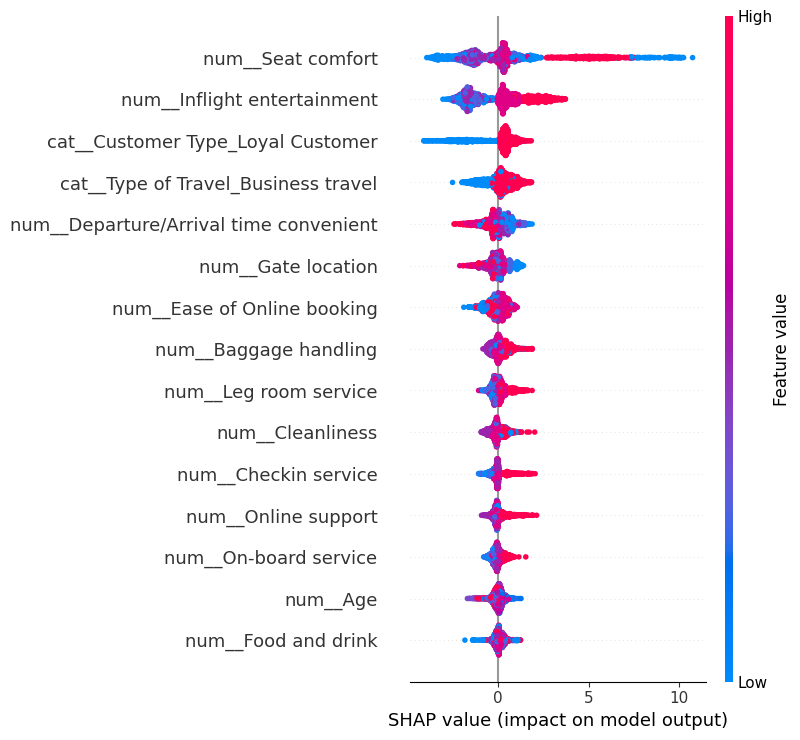

In [212]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, max_display=15)

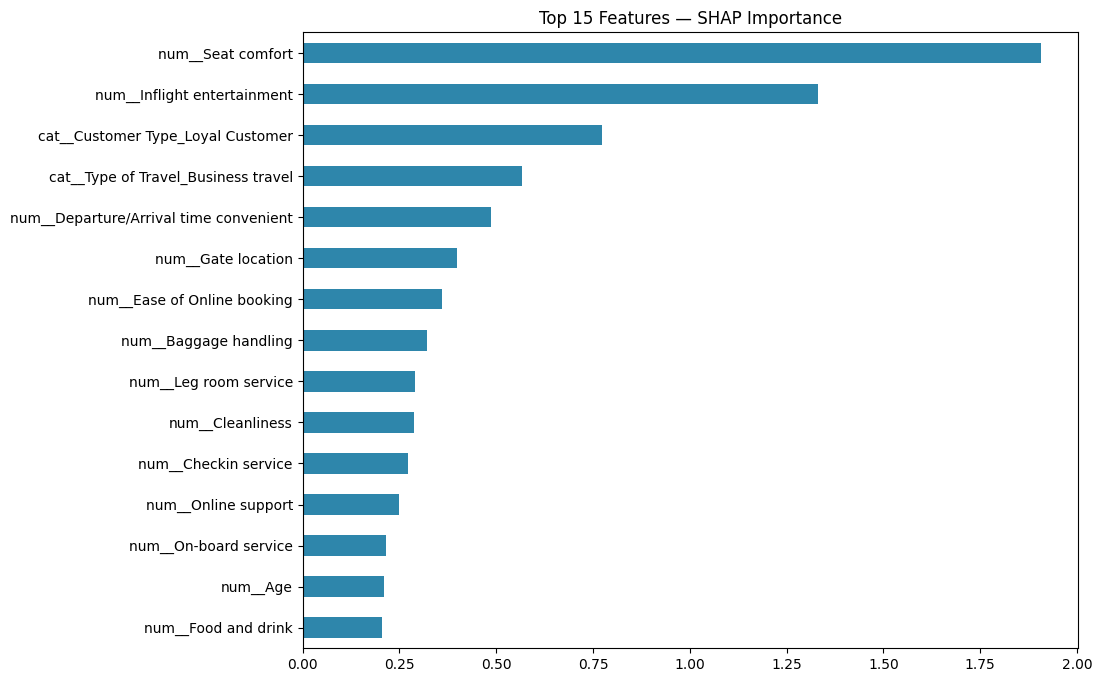

,0
num__Seat comfort,1.906230
num__Inflight entertainment,1.331673
cat__Customer Type_Loyal Customer,0.773826
cat__Type of Travel_Business travel,0.565465
num__Departure/Arrival time convenient,0.487281
num__Gate location,0.399523
num__Ease of Online booking,0.360101
num__Baggage handling,0.321286
num__Leg room service,0.291156
num__Cleanliness,0.287719


In [213]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
shap_importance.head(15).plot(kind='barh', color='#2E86AB')
plt.title('Top 15 Features — SHAP Importance')
plt.gca().invert_yaxis()
plt.show()

shap_importance.head(15)

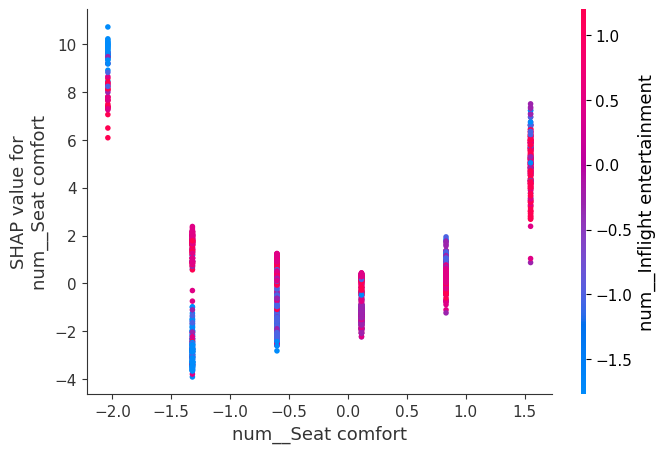

In [214]:
shap.dependence_plot('num__Seat comfort', shap_values, X_test_transformed, feature_names=feature_names)

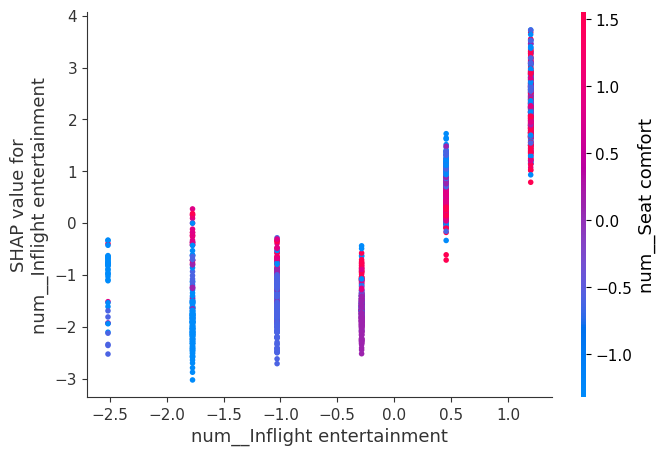

In [215]:
shap.dependence_plot('num__Inflight entertainment', shap_values, X_test_transformed, feature_names=feature_names)

## Feature Importance & Explainability (SHAP)

Used `shap.TreeExplainer` on the tuned XGBoost model (on a 2,000-row sample
of the test set for computational efficiency) to understand not just which
features matter, but how they push predictions toward "satisfied" or
"dissatisfied".

Top drivers by mean absolute SHAP value:
1. Seat comfort
2. Inflight entertainment
3. Customer Type (disloyal)
4. Type of Travel (Personal)
5. Departure/Arrival time convenient

Key findings, directly answering the roadmap's explainability questions:
- **Service quality dominates**: Seat comfort and Inflight entertainment are
  by far the strongest individual predictors, consistent with the
  correlation and mutual-information results from Sections 5 and 8 — SHAP
  confirms this while additionally accounting for feature interactions.
- **Delay has limited impact**: Arrival Delay ranks around 17th in
  importance, reinforcing the earlier finding that delays are a weaker
  driver of satisfaction than service quality.
- **New insight not obvious from earlier sections**: Customer loyalty status
  and travel type (Personal vs Business) turned out to be stronger
  predictors than most individual service ratings — disloyal customers and
  personal travelers show a systematic tilt toward dissatisfaction largely
  independent of service quality itself.

This explainability step both validates the earlier EDA/feature-selection
conclusions and surfaces a new, business-relevant insight (loyalty and
travel-type effects) that will feed directly into Section 21.

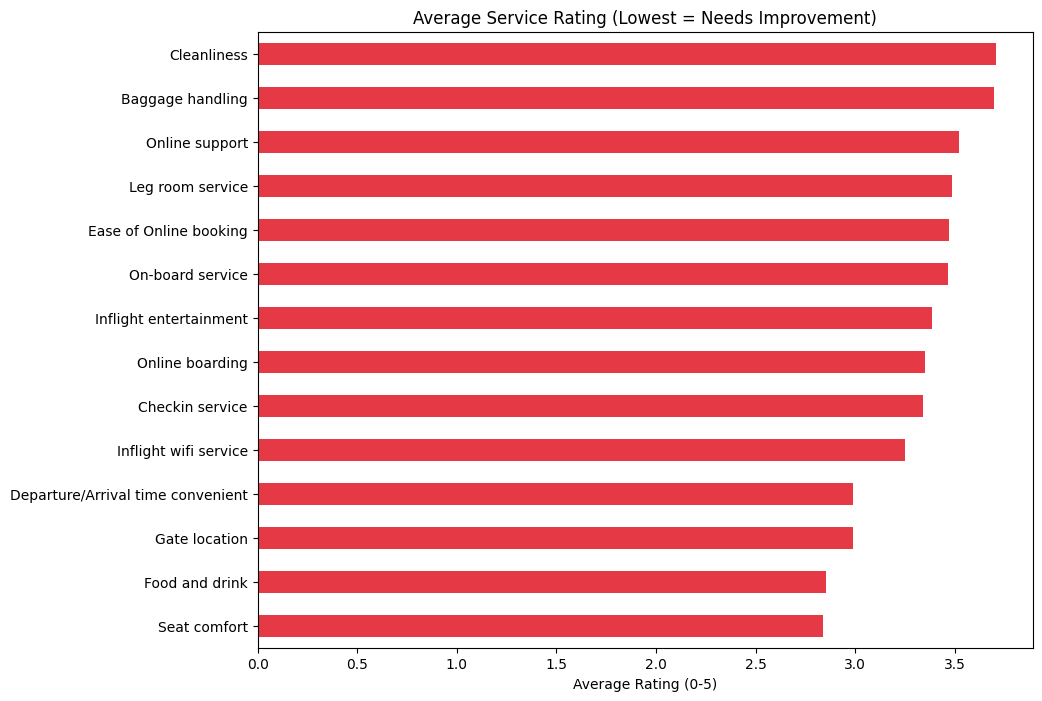

,0
Seat comfort,2.838597
Food and drink,2.851994
Gate location,2.990422
Departure/Arrival time convenient,2.990645
Inflight wifi service,3.249130
Checkin service,3.340807
Online boarding,3.352587
Inflight entertainment,3.383477
On-board service,3.465075
Ease of Online booking,3.472105


In [217]:
service_avg_ratings = df[rating_columns].mean().sort_values()

plt.figure(figsize=(10, 8))
service_avg_ratings.plot(kind='barh', color='#E63946')
plt.title('Average Service Rating (Lowest = Needs Improvement)')
plt.xlabel('Average Rating (0-5)')
plt.show()

service_avg_ratings

In [218]:
loyalty_class = pd.crosstab([df['Customer Type'], df['Class']],
                             df['satisfaction'], normalize='index') * 100
loyalty_class

satisfaction                dissatisfied  satisfied
Customer Type     Class                            
Loyal Customer    Business     23.608986  76.391014
                  Eco          52.975937  47.024063
                  Eco Plus     53.554614  46.445386
disloyal Customer Business     60.329325  39.670675
                  Eco          85.587502  14.412498
                  Eco Plus     92.021858   7.978142

In [219]:
df['has_delay'] = (df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']) > 15

delay_by_loyalty = df.groupby(['Customer Type', 'has_delay'])['satisfaction'] \
    .apply(lambda x: (x == 'satisfied').mean())
delay_by_loyalty

Customer Type      has_delay
Loyal Customer     False        0.647938
                   True         0.543912
disloyal Customer  False        0.258687
                   True         0.197704
Name: satisfaction, dtype: float64

In [220]:
recommendations = """
1. Priority #1: Improve Seat Comfort — lowest-rated AND highest-impact service (SHAP rank #1).
2. Priority #2: Improve Food & Drink quality — second-lowest rating, though lower SHAP impact.
3. At-risk segment: disloyal customers in Eco/Eco Plus (8-14% satisfaction) —
   consider targeted loyalty programs or service recovery for this group specifically.
4. Delays matter less than expected — operational fixes for on-time performance
   should NOT be prioritized over service-quality investments.
5. Personal travelers report lower satisfaction than business travelers —
   worth investigating whether pricing/amenities for personal travel need rethinking.
"""
print(recommendations)


1. Priority #1: Improve Seat Comfort — lowest-rated AND highest-impact service (SHAP rank #1).
2. Priority #2: Improve Food & Drink quality — second-lowest rating, though lower SHAP impact.
3. At-risk segment: disloyal customers in Eco/Eco Plus (8-14% satisfaction) — 
   consider targeted loyalty programs or service recovery for this group specifically.
4. Delays matter less than expected — operational fixes for on-time performance 
   should NOT be prioritized over service-quality investments.
5. Personal travelers report lower satisfaction than business travelers — 
   worth investigating whether pricing/amenities for personal travel need rethinking.



In [221]:
import joblib

# نحفظ الـ Pipeline كامل (preprocessing + tuned XGBoost) في ملف واحد
joblib.dump(best_xgb_pipeline, 'airline_satisfaction_model.pkl')

# نحفظ الـ label encoder كمان عشان يعرف 0/1 معناها إيه
joblib.dump(label_encoder, 'label_encoder.pkl')

print("✅ Model saved as airline_satisfaction_model.pkl")
print("✅ Label encoder saved as label_encoder.pkl")

✅ Model saved as airline_satisfaction_model.pkl
✅ Label encoder saved as label_encoder.pkl
